# Noise Cancelling filter for corrupt radio signals

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# create a smooth sine wave representing a clean sound freq.
wave=np.linspace(0,4*np.pi,500) 
# 500 points between o and 10

wave


array([ 0.        ,  0.02004008,  0.04008016,  0.06012024,  0.08016032,
        0.1002004 ,  0.12024048,  0.14028056,  0.16032064,  0.18036072,
        0.2004008 ,  0.22044088,  0.24048096,  0.26052104,  0.28056112,
        0.3006012 ,  0.32064128,  0.34068136,  0.36072144,  0.38076152,
        0.4008016 ,  0.42084168,  0.44088176,  0.46092184,  0.48096192,
        0.501002  ,  0.52104208,  0.54108216,  0.56112224,  0.58116232,
        0.6012024 ,  0.62124248,  0.64128257,  0.66132265,  0.68136273,
        0.70140281,  0.72144289,  0.74148297,  0.76152305,  0.78156313,
        0.80160321,  0.82164329,  0.84168337,  0.86172345,  0.88176353,
        0.90180361,  0.92184369,  0.94188377,  0.96192385,  0.98196393,
        1.00200401,  1.02204409,  1.04208417,  1.06212425,  1.08216433,
        1.10220441,  1.12224449,  1.14228457,  1.16232465,  1.18236473,
        1.20240481,  1.22244489,  1.24248497,  1.26252505,  1.28256513,
        1.30260521,  1.32264529,  1.34268537,  1.36272545,  1.38

In [ ]:
wave=np.sin(wave) # sine value of those points using np.sin
wave

array([ 0.        ,  0.02003874,  0.04006943,  0.06008403,  0.0800745 ,
        0.10003281,  0.11995096,  0.13982093,  0.15963474,  0.17938446,
        0.19906213,  0.21865986,  0.23816978,  0.25758405,  0.27689487,
        0.2960945 ,  0.31517522,  0.33412937,  0.35294934,  0.37162756,
        0.39015654,  0.40852884,  0.42673708,  0.44477394,  0.46263218,
        0.48030464,  0.49778421,  0.51506387,  0.53213669,  0.54899581,
        0.56563445,  0.58204594,  0.59822369,  0.61416119,  0.62985206,
        0.64528998,  0.66046875,  0.67538229,  0.6900246 ,  0.70438981,
        0.71847213,  0.73226593,  0.74576565,  0.75896588,  0.77186131,
        0.78444678,  0.79671721,  0.80866769,  0.82029342,  0.83158972,
        0.84255206,  0.85317605,  0.8634574 ,  0.873392  ,  0.88297585,
        0.89220511,  0.90107606,  0.90958515,  0.91772896,  0.92550421,
        0.93290779,  0.93993672,  0.94658819,  0.95285951,  0.95874817,
        0.96425181,  0.96936821,  0.97409532,  0.97843124,  0.98

In [9]:
# creating random static to corrupt the existing clean wave
corrupt=np.random.rand(500)
corrupt*=0.3
corrupt

array([0.21911402, 0.10358098, 0.15172257, 0.11569098, 0.29780885,
       0.22756552, 0.27577094, 0.28268756, 0.12585578, 0.14857074,
       0.20114856, 0.19275269, 0.23265712, 0.21445089, 0.09076876,
       0.29389719, 0.04798056, 0.0655574 , 0.22975561, 0.1286628 ,
       0.08411273, 0.26977735, 0.05325971, 0.16311336, 0.17473717,
       0.13937403, 0.15705555, 0.14415684, 0.24630628, 0.09518703,
       0.21597144, 0.25779354, 0.08441261, 0.03306666, 0.18090028,
       0.05464824, 0.24483484, 0.19175708, 0.04100871, 0.17156363,
       0.11920253, 0.16077874, 0.08963004, 0.19013455, 0.19022274,
       0.28981063, 0.188498  , 0.09334325, 0.05882655, 0.05096031,
       0.23944317, 0.25608039, 0.05368631, 0.27653959, 0.17719145,
       0.00218621, 0.21826289, 0.26197803, 0.29240156, 0.13968842,
       0.20751474, 0.05488144, 0.01145753, 0.28069886, 0.13873865,
       0.08254417, 0.25700975, 0.15651475, 0.24911057, 0.08671706,
       0.22343661, 0.13813298, 0.2076798 , 0.02409546, 0.09672

In [8]:
#creating a realistic signal value 
signal=wave+corrupt
signal

array([ 0.163894  ,  0.30318704,  0.12879505,  0.06201566,  0.29799406,
        0.24645383,  0.12883281,  0.22181295,  0.36008658,  0.26919107,
        0.31825045,  0.44036144,  0.25333054,  0.45118291,  0.48031346,
        0.45675347,  0.547485  ,  0.50254956,  0.50389933,  0.4113734 ,
        0.58405062,  0.49853212,  0.57125311,  0.63031426,  0.59265677,
        0.67563314,  0.7517205 ,  0.69172303,  0.83254761,  0.81486353,
        0.74165221,  0.62962832,  0.91992846,  0.75723145,  0.86925626,
        0.7903846 ,  0.91236457,  0.78373397,  0.8964491 ,  0.84372548,
        0.95810713,  0.84269569,  0.93355669,  1.03219683,  1.0739237 ,
        1.13602417,  1.01820904,  1.01047118,  1.25793997,  1.13250899,
        1.1077392 ,  1.09543417,  1.11584533,  1.29096179,  1.36501985,
        1.23268956,  1.1723488 ,  1.26808971,  1.23787837,  1.32053075,
        1.48587849,  1.43927475,  1.51888945,  1.26284909,  1.53042166,
        1.52356768,  1.41526935,  1.38581271,  1.52448721,  1.61

In [10]:
# Now we need to smoothen out the spikes to recover the original wave
np.convolve(signal,np.ones(10)/10,mode='valid') 
#convolve the signal with a kernel of ones to smoothen it out.The kernel is of size 10 and is normalized by dividing by 10 to maintain the same scale as the original signal. The mode 'valid' ensures that only the valid part of the convolution is returned, which means that the output will be smaller than the input signal by the size of the kernel minus one. This operation will help to reduce the noise in the signal and recover a smoother version of the original wave.


array([ 0.21822631,  0.23366195,  0.24737939,  0.25983294,  0.29874966,
        0.3169816 ,  0.33801157,  0.37987679,  0.40795045,  0.42233172,
        0.43654995,  0.46312997,  0.46894704,  0.5007393 ,  0.51865243,
        0.52988676,  0.55177473,  0.57219828,  0.59111563,  0.62398045,
        0.66432947,  0.68008963,  0.69319925,  0.72806678,  0.7407585 ,
        0.76841845,  0.7798936 ,  0.795958  ,  0.8051591 ,  0.81154925,
        0.81443544,  0.83608093,  0.85738767,  0.85875049,  0.88624703,
        0.90671378,  0.94127773,  0.95186218,  0.9745359 ,  1.01068499,
        1.03956334,  1.05452655,  1.07980039,  1.09802926,  1.12390575,
        1.15301537,  1.16268191,  1.17809588,  1.20385774,  1.20185158,
        1.22065375,  1.25846768,  1.29285174,  1.33315615,  1.33034488,
        1.34688506,  1.37597287,  1.40026493,  1.41203723,  1.44069811,
        1.47049645,  1.47118833,  1.49849552,  1.50210112,  1.53148556,
        1.55130944,  1.57605926,  1.61248288,  1.64679627,  1.65

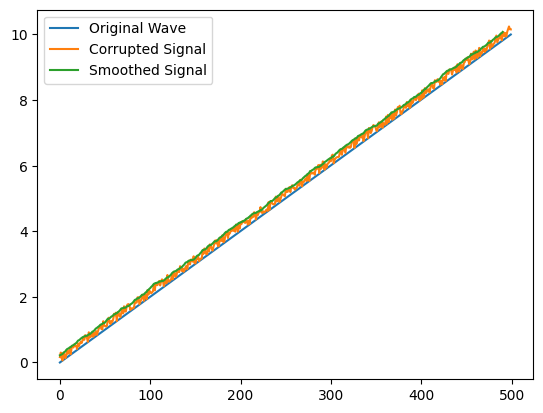

In [11]:
plt.plot(wave,label='Original Wave')
plt.plot(signal,label='Corrupted Signal')   
plt.plot(np.convolve(signal,np.ones(10)/10,mode='valid'),label='Smoothed Signal')
plt.legend()
plt.show()